# Maternal Health Risk Prediction

## Exploratory Data Analysis (EDA)

### Project Overview
This notebook performs Exploratory Data Analysis (EDA) on the Maternal Health Risk Dataset.

### Objectives
- Understand dataset structure
- Analyze missing values
- Identify duplicate records
- Study continuous variables
- Analyze categorical variables
- Explore feature relationships
- Detect outliers
- Generate statistical insights

#### Import Required Libraries

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

import missingno as msno
import math

from scipy.stats import kurtosis

sns.set_style("whitegrid")

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

#### Load Dataset

In [2]:
data = pd.read_csv("../Dataset/Maternal Health Risk Data Set.csv")

print("Dataset Loaded Successfully")

Dataset Loaded Successfully


### Dataset Overview

#### Dataset Shape

In [3]:
data.shape

(1014, 7)

#### Dataset Information

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1014 entries, 0 to 1013
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          1014 non-null   int64  
 1   SystolicBP   1014 non-null   int64  
 2   DiastolicBP  1014 non-null   int64  
 3   BS           1014 non-null   float64
 4   BodyTemp     1014 non-null   float64
 5   HeartRate    1014 non-null   int64  
 6   RiskLevel    1014 non-null   object 
dtypes: float64(2), int64(4), object(1)
memory usage: 55.6+ KB


#### Preview Dataset

In [5]:
data.head()

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel
0,25,130,80,15.0,98.0,86,high risk
1,35,140,90,13.0,98.0,70,high risk
2,29,90,70,8.0,100.0,80,high risk
3,30,140,85,7.0,98.0,70,high risk
4,35,120,60,6.1,98.0,76,low risk


#### Feature Names

In [6]:
data.columns

Index(['Age', 'SystolicBP', 'DiastolicBP', 'BS', 'BodyTemp', 'HeartRate',
       'RiskLevel'],
      dtype='object')

### Duplicate Records Analysis

#### Duplicate Records Statistics

In [7]:
#  Calculate duplicates
duplicate_count = data.duplicated().sum()
total_rows = len(data)
non_duplicate_count = total_rows - duplicate_count

duplicate_percentage = (duplicate_count / total_rows) * 100 if total_rows else 0
non_duplicate_percentage = 100 - duplicate_percentage

# Summary DataFrame
duplicate_summary = pd.DataFrame({
    'Any Duplicates?': [duplicate_count > 0],
    'Number of Duplicates': [duplicate_count],
    'Duplicate Percentage (%)': [duplicate_percentage],
    'Non-Duplicate Percentage (%)': [non_duplicate_percentage]
})

print("Duplicate Summary:")
display(duplicate_summary)

# ============================
# 📌 Display duplicate rows
# ============================

if duplicate_count > 0:
    duplicate_rows = data[data.duplicated(keep=False)]
    print("\nDuplicate Records:")
    display(duplicate_rows)
else:
    print("\nNo duplicate records to display.")


Duplicate Summary:


,Any Duplicates?,Number of Duplicates,Duplicate Percentage (%),Non-Duplicate Percentage (%)
0,True,562,55.424063,44.575937



Duplicate Records:


,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel
1,35,140,90,13.00,98.0,70,high risk
2,29,90,70,8.00,100.0,80,high risk
3,30,140,85,7.00,98.0,70,high risk
4,35,120,60,6.10,98.0,76,low risk
5,23,140,80,7.01,98.0,70,high risk
...,...,...,...,...,...,...,...
1009,22,120,60,15.00,98.0,80,high risk
1010,55,120,90,18.00,98.0,60,high risk
1011,35,85,60,19.00,98.0,86,high risk
1012,43,120,90,18.00,98.0,70,high risk


#### Duplicate Records Visualization

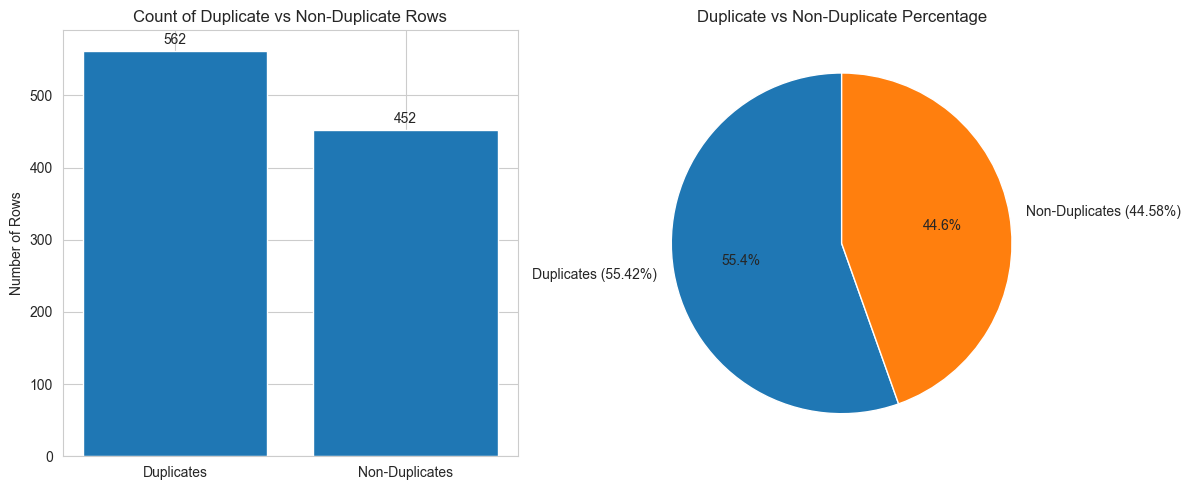

In [8]:
# ============================
# 📌 Prepare values for plotting
# ============================

labels = ['Duplicates', 'Non-Duplicates']
counts = [duplicate_count, non_duplicate_count]
percentages = [duplicate_percentage, non_duplicate_percentage]

# ============================
# 📌 Create side-by-side plots
# ============================

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- (1) Bar Chart: Counts ---
axes[0].bar(labels, counts)
axes[0].set_title('Count of Duplicate vs Non-Duplicate Rows')
axes[0].set_ylabel('Number of Rows')

# Annotate bars with count values
for i, v in enumerate(counts):
    axes[0].text(i, v + max(counts) * 0.01, str(v), ha='center', va='bottom')

# --- (2) Pie Chart: Percentages ---
pie_labels = [f'{lab} ({pct:.2f}%)' for lab, pct in zip(labels, percentages)]
axes[1].pie(counts, labels=pie_labels, autopct='%1.1f%%', startangle=90)
axes[1].set_title('Duplicate vs Non-Duplicate Percentage')

plt.tight_layout()
plt.show()

### Missing Value Analysis 

#### Missing Value Statistics

In [9]:
# ---- Missing Value Summary Table ----
missing_summary = pd.DataFrame({
    'Feature': data.columns,
    'Any Null?': data.isnull().any().values,
    'Null Count': data.isnull().sum().values,
    'Null Percentage (%)': (data.isnull().sum().values / len(data) * 100).round(2),
    'Non-Null Count': data.notnull().sum().values,
    'Non-Null Percentage (%)': (data.notnull().sum().values / len(data) * 100).round(2)
})

# Display the summary
display(missing_summary)

,Feature,Any Null?,Null Count,Null Percentage (%),Non-Null Count,Non-Null Percentage (%)
0,Age,False,0,0.0,1014,100.0
1,SystolicBP,False,0,0.0,1014,100.0
2,DiastolicBP,False,0,0.0,1014,100.0
3,BS,False,0,0.0,1014,100.0
4,BodyTemp,False,0,0.0,1014,100.0
5,HeartRate,False,0,0.0,1014,100.0
6,RiskLevel,False,0,0.0,1014,100.0


#### Missing Value Visualization

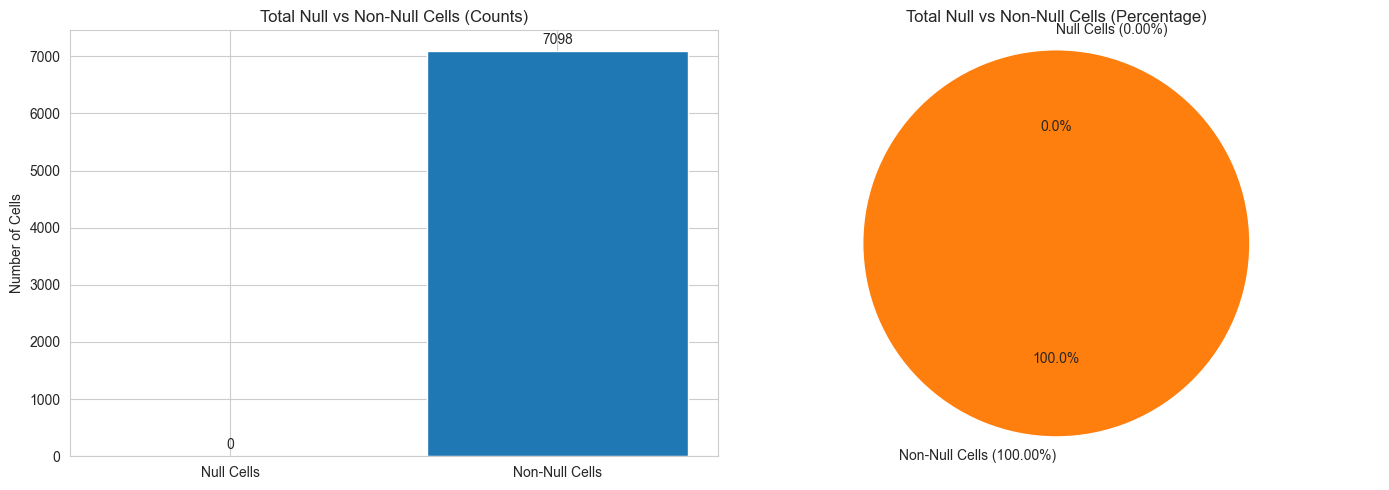


No column-level null values. Column-based charts skipped.


In [10]:
# --- Overall null stats ---
total_cells = data.size
total_nulls = data.isnull().sum().sum()
total_non_nulls = total_cells - total_nulls

# ============================================================
# 🔵 FIRST ROW (Always show bar + pie)
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
labels = ['Null Cells', 'Non-Null Cells']
counts = [total_nulls, total_non_nulls]
axes[0].bar(labels, counts)
axes[0].set_title('Total Null vs Non-Null Cells (Counts)')
axes[0].set_ylabel('Number of Cells')
for i, v in enumerate(counts):
    axes[0].text(i, v + max(counts)*0.01, str(int(v)), ha='center', va='bottom')

# Pie chart
percentages = [(c / total_cells) * 100 for c in counts]
pie_labels = [f'{lab} ({pct:.2f}%)' for lab, pct in zip(labels, percentages)]
axes[1].pie(counts, labels=pie_labels, autopct='%1.1f%%', startangle=90)
axes[1].set_title('Total Null vs Non-Null Cells (Percentage)')
axes[1].axis('equal')

plt.tight_layout()
plt.show()

# ============================================================
# 🔵 SECOND + THIRD ROW ONLY IF NULLS EXIST
# ============================================================

if total_nulls > 0:
    # ==================================================================
    # SECOND ROW → Stacked bar chart for null/non-null per column
    # ==================================================================
    cols = data.columns.tolist()
    null_counts = data.isnull().sum().values
    non_null_counts = data.notnull().sum().values

    fig, ax = plt.subplots(figsize=(12, 6))
    x = np.arange(len(cols))
    ax.bar(x, non_null_counts, label='Non-Null Count')
    ax.bar(x, null_counts, bottom=non_null_counts, label='Null Count')
    ax.set_xticks(x)
    ax.set_xticklabels(cols, rotation=45, ha='right')
    ax.set_ylabel('Number of Rows')
    ax.set_title('Null vs Non-Null Counts by Column (Stacked)')
    ax.legend()

    for i in range(len(cols)):
        total_val = non_null_counts[i] + null_counts[i]
        ax.text(i, total_val + max(total_val*0.01, 1), str(int(total_val)),
                ha='center', va='bottom')

    plt.tight_layout()
    plt.show()

    # ==================================================================
    # THIRD ROW → Donut chart for each column
    # ==================================================================
    n_cols = 3  
    n_plots = len(cols)
    n_rows = math.ceil(n_plots / n_cols)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
    axes = np.array(axes).reshape(-1)

    for i, col in enumerate(cols):
        ax = axes[i]
        col_null = int(null_counts[i])
        col_non_null = int(non_null_counts[i])
        total = col_null + col_non_null

        values = [col_null, col_non_null]
        pct_null = (col_null / total) * 100
        pct_non_null = (col_non_null / total) * 100

        donut_labels = [
            f'Null ({pct_null:.2f}%)',
            f'Non-Null ({pct_non_null:.2f}%)'
        ]

        ax.pie(values, labels=donut_labels, autopct='%1.1f%%',
               startangle=90, wedgeprops={'width': 0.4})
        ax.set_title(f'Null vs Non-Null % — {col}')
        ax.axis('equal')

    # Hide empty plots
    for j in range(n_plots, n_rows*n_cols):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

else:
    print("\nNo column-level null values. Column-based charts skipped.")

### Continuous Variable Analysis

#### Continuous Feature Selection

In [11]:
data_cont = data[['Age', 'SystolicBP', 'DiastolicBP', 'BS', 'BodyTemp', 'HeartRate']]

#### Continuous Statistics

In [12]:
#  Distribution Summary for Continuous Features (Your Dataset)
summary_list = []

for col in data_cont.columns:
    col_data = data_cont[col]

    mini = col_data.min()
    maxi = col_data.max()
    rangi = maxi - mini
    mean = col_data.mean()
    median = col_data.median()
    
    # Mode using your formula
    mode_formula = round(3 * median - 2 * mean, 3)

    std_dev = col_data.std()
    variance = col_data.var()
    skewness = col_data.skew()
    kurt = col_data.kurtosis()

    q1 = col_data.quantile(0.25)
    q2 = col_data.quantile(0.50)
    q3 = col_data.quantile(0.75)

    any_zero = (col_data == 0).any()
    any_positive = (col_data > 0).any()
    any_negative = (col_data < 0).any()

    summary_list.append({
        'Feature': col,
        'Min': mini,
        'Max': maxi,
        'Range': rangi,
        'Mean': mean,
        'Median': median,
        'Mode_rel': mode_formula,
        'Std Dev': round(std_dev, 3),
        'Variance': round(variance, 3),
        'Skewness': round(skewness, 3),
        'Kurtosis': round(kurt, 3),
        'Q1': round(q1, 3),
        'Q2': round(q2, 3),
        'Q3': round(q3, 3),
        'Any Zero?': any_zero,
        'Any Positive?': any_positive,
        'Any Negative?': any_negative
    })

distribution_summary = pd.DataFrame(summary_list)
pd.set_option('display.max_columns', None)

display(distribution_summary)

,Feature,Min,Max,Range,Mean,Median,Mode_rel,Std Dev,Variance,Skewness,Kurtosis,Q1,Q2,Q3,Any Zero?,Any Positive?,Any Negative?
0,Age,10.0,70.0,60.0,29.871795,26.0,18.256,13.474,181.559,0.783,-0.391,19.0,26.0,39.0,False,True,False
1,SystolicBP,70.0,160.0,90.0,113.198225,120.0,133.604,18.404,338.704,-0.251,-0.613,100.0,120.0,120.0,False,True,False
2,DiastolicBP,49.0,100.0,51.0,76.460552,80.0,87.079,13.886,192.815,-0.048,-0.949,65.0,80.0,90.0,False,True,False
3,BS,6.0,19.0,13.0,8.725986,7.5,5.048,3.294,10.847,1.868,2.303,6.9,7.5,8.0,False,True,False
4,BodyTemp,98.0,103.0,5.0,98.665089,98.0,96.670,1.371,1.881,1.751,1.452,98.0,98.0,98.0,False,True,False
5,HeartRate,7.0,90.0,83.0,74.301775,76.0,79.396,8.089,65.427,-1.044,8.399,70.0,76.0,80.0,False,True,False


#### Continuous Visualizations


======================== Age ========================



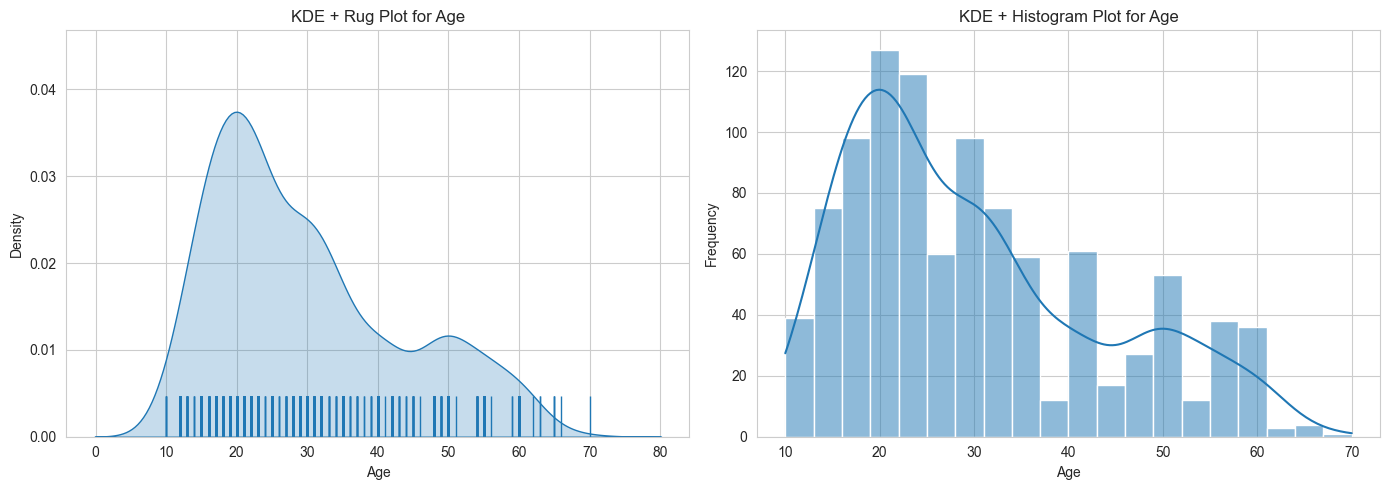


======================== SystolicBP ========================



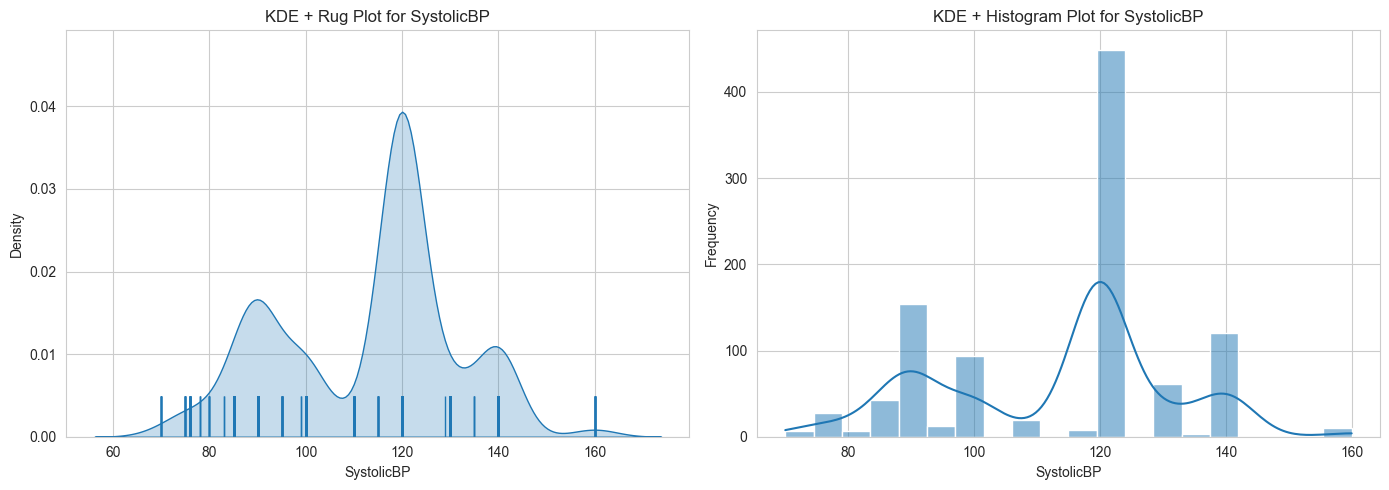


======================== DiastolicBP ========================



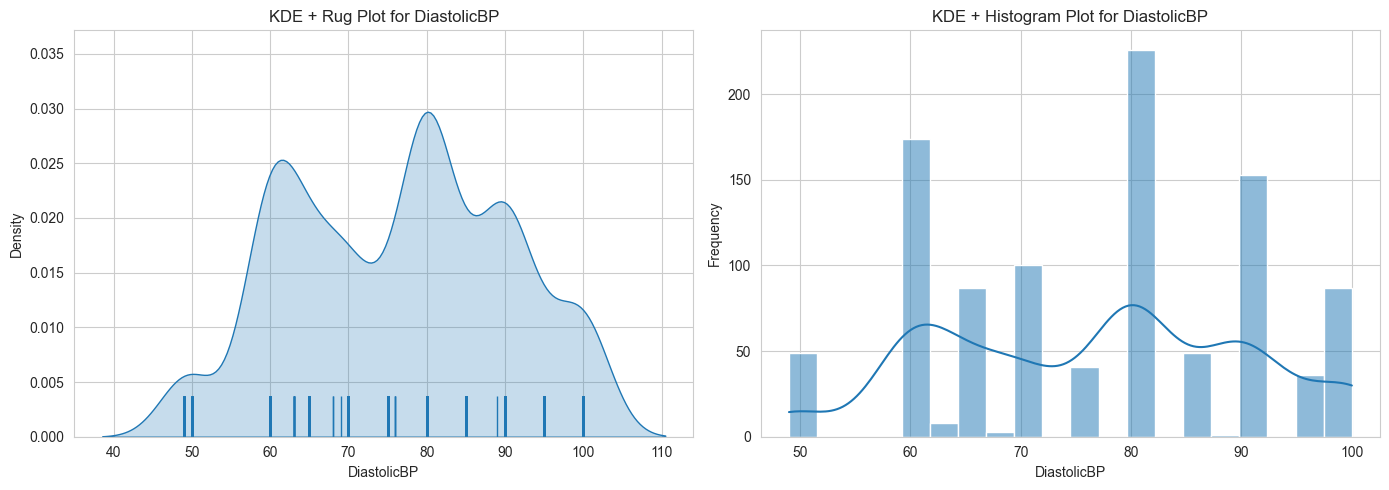


======================== BS ========================



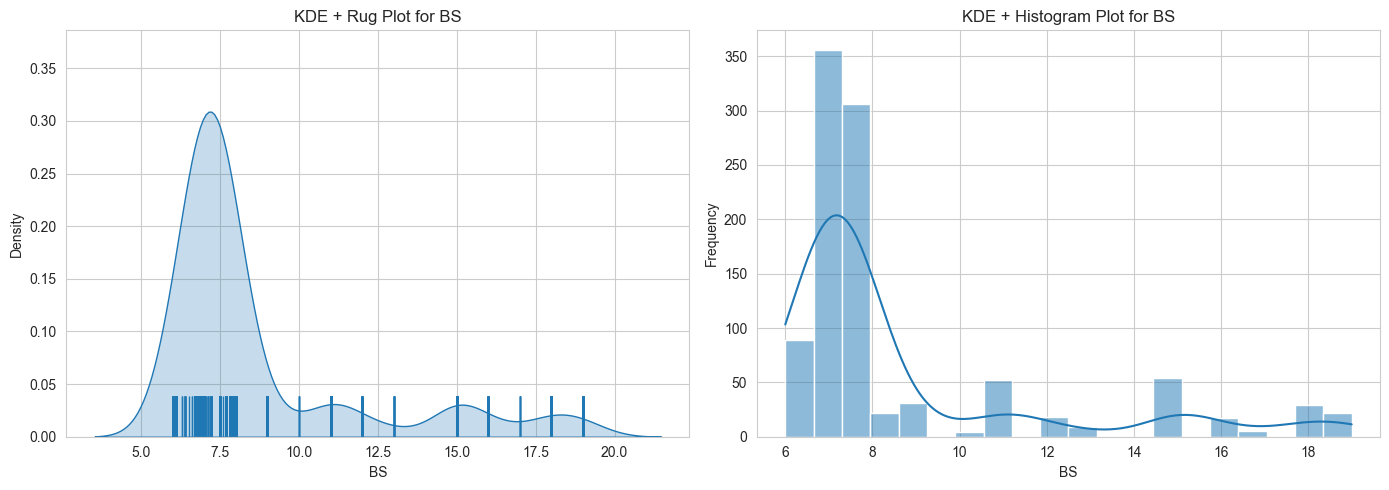


======================== BodyTemp ========================



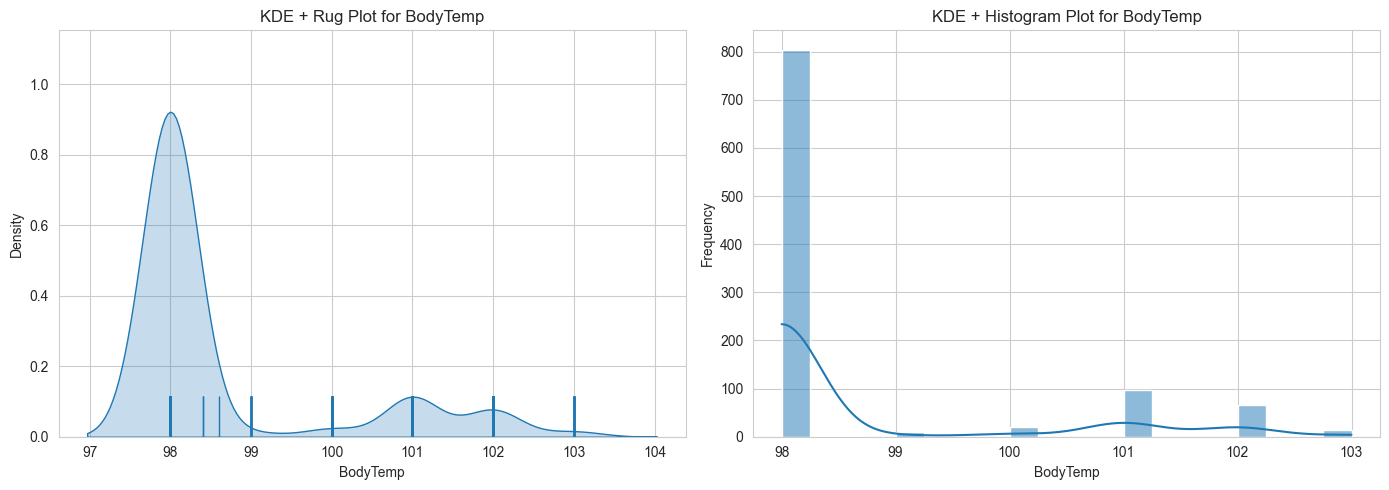


======================== HeartRate ========================



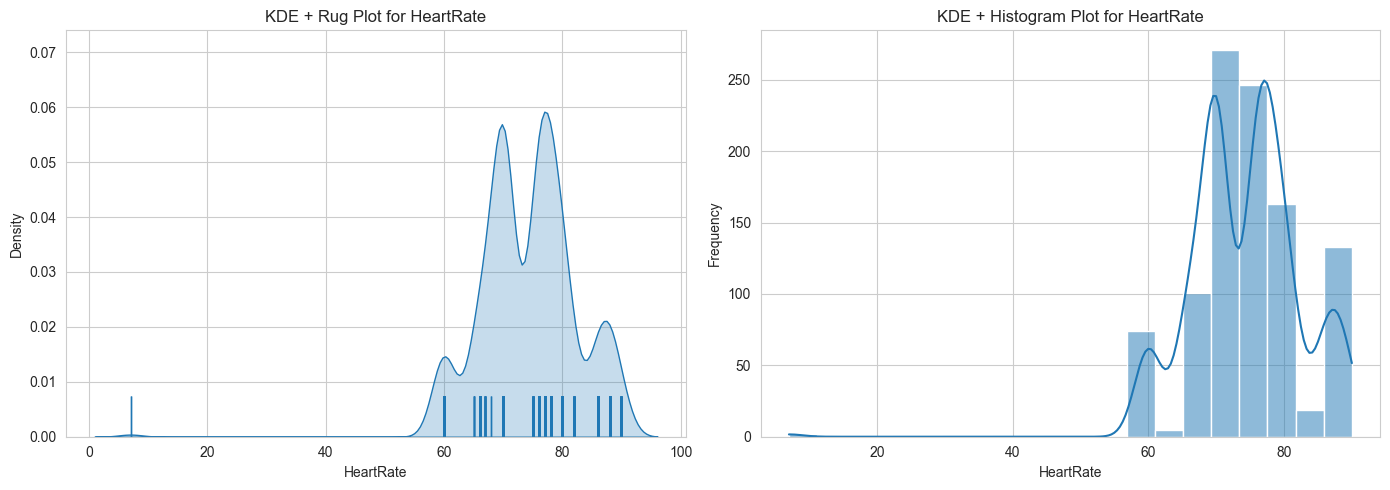

In [13]:
# Loop through each continuous column in your dataset
for col in data_cont.columns:
    col_data = data_cont[col].dropna()

    print(f"\n======================== {col} ========================\n")

    # Create 1 row → 2 columns layout
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # ---------------------------------------------------------
    # LEFT: KDE + Rug
    # ---------------------------------------------------------
    sns.kdeplot(col_data, fill=True, ax=axes[0])
    sns.rugplot(col_data, height=0.1, ax=axes[0])
    axes[0].set_title(f"KDE + Rug Plot for {col}")
    axes[0].set_xlabel(col)
    axes[0].set_ylabel("Density")

    # ---------------------------------------------------------
    # RIGHT: KDE + Histogram
    # ---------------------------------------------------------
    sns.histplot(col_data, kde=True, bins=20, ax=axes[1])
    axes[1].set_title(f"KDE + Histogram Plot for {col}")
    axes[1].set_xlabel(col)
    axes[1].set_ylabel("Frequency")

    plt.tight_layout()
    plt.show()

### Categorical Variable Analysis

#### Categorical Feature Selection

In [14]:
data_cat = data[['RiskLevel']]

#### Categorical Statistics

In [15]:
# Parameters you can tweak
top_n = 6                   # how many top categories to show (others → 'Other')
figsize_per_row = (18, 6)   # figure size for the 1x3 row (width, height)

# ============================
# 📌 Unique Summary for Categorical Columns
# ============================

pd.set_option('display.max_colwidth', None)

unique_summary = pd.DataFrame({
    'Feature': data_cat.columns,
    'Unique Values': [data_cat[col].unique() for col in data_cat.columns],
    'No. of Unique Values (nunique)': [data_cat[col].nunique() for col in data_cat.columns],
    'Value Counts (Top 5)': [data_cat[col].value_counts().head(5).to_dict() for col in data_cat.columns]
})

display(unique_summary)

,Feature,Unique Values,No. of Unique Values (nunique),Value Counts (Top 5)
0,RiskLevel,"[high risk, low risk, mid risk]",3,"{'low risk': 406, 'mid risk': 336, 'high risk': 272}"


#### Categorical Visualizations

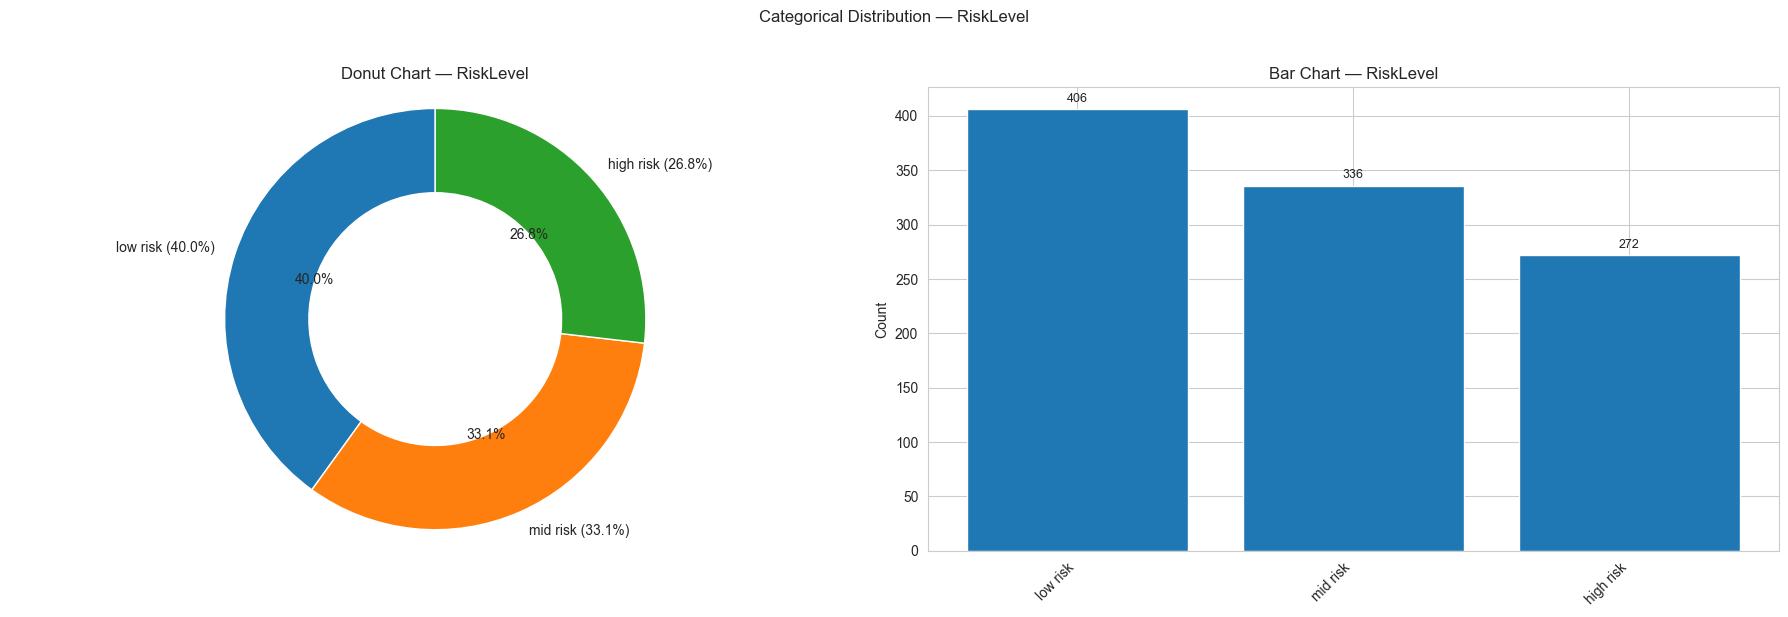

In [16]:
# Loop through each categorical column and draw 1 row with 2 plots:
# [LEFT]  -> donut chart (pie with hole) for distribution (top categories + Other)
# [RIGHT] -> regular bar chart (counts)

for col in data_cat.columns:
    vc = data_cat[col].value_counts(dropna=False)  # include NaN as a category if present
    total = vc.sum()

    # Aggregate to top_n categories, rest as 'Other'
    if len(vc) > top_n:
        top = vc.iloc[: top_n - 1].copy()  # keep top_n-1 explicit categories
        other_sum = vc.iloc[top_n - 1 :].sum()
        top['Other'] = other_sum
        plot_counts = top
    else:
        plot_counts = vc

    labels = plot_counts.index.astype(str).tolist()
    counts = plot_counts.values.tolist()
    percentages = [(c / total) * 100 for c in counts]

    # Create 1x2 subplot row
    fig, axes = plt.subplots(1, 2, figsize=figsize_per_row)

    # -----------------------------
    # LEFT: Donut chart (pie with hole)
    # -----------------------------
    ax = axes[0]
    donut_labels = [f"{lab} ({pct:.1f}%)" for lab, pct in zip(labels, percentages)]
    wedges, texts, autotexts = ax.pie(
        counts,
        labels=donut_labels,
        autopct='%1.1f%%',
        startangle=90,
        wedgeprops={'width': 0.4}
    )
    ax.set_title(f'Donut Chart — {col}')
    ax.axis('equal')

    # -----------------------------
    # RIGHT: Regular bar chart with counts
    # -----------------------------
    ax = axes[1]
    x_pos = np.arange(len(labels))
    ax.bar(x_pos, counts)
    ax.set_xticks(x_pos)
    ax.set_xticklabels(labels, rotation=45, ha='right')
    ax.set_ylabel('Count')
    ax.set_title(f'Bar Chart — {col}')

    # annotate bars with counts on top
    for i, v in enumerate(counts):
        ax.text(i, v + max(counts) * 0.01, str(int(v)), ha='center', va='bottom', fontsize=9)

    plt.suptitle(f'Categorical Distribution — {col}', fontsize=12, y=1.02)
    plt.tight_layout()
    plt.show()

### Continuous vs Categorical Analysis

#### RiskLevel Based Analysis


======================== Plotting: Age ========================



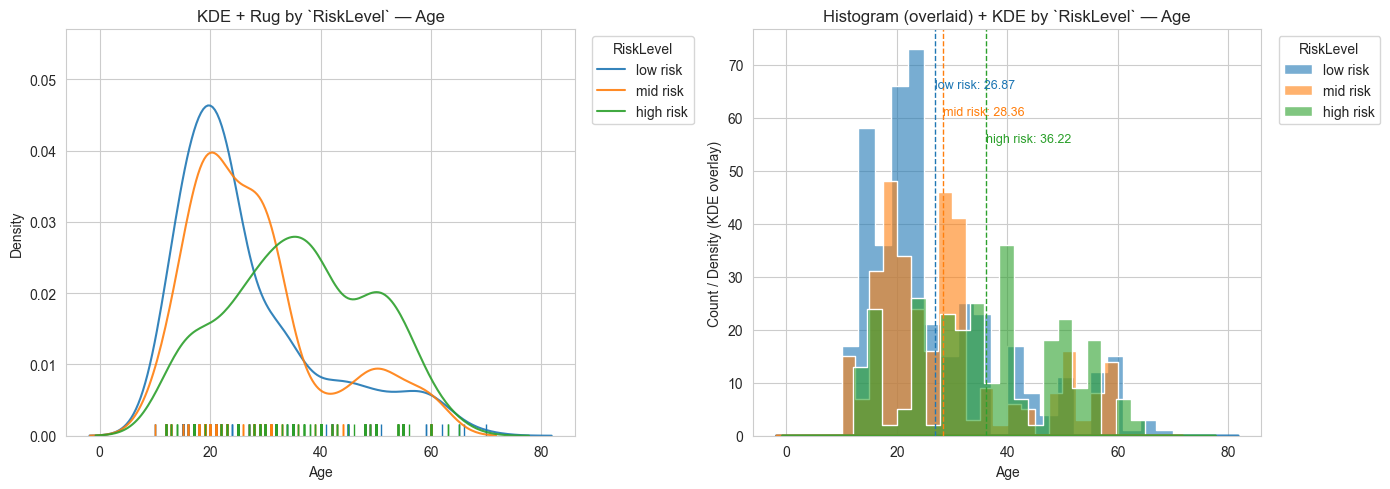


======================== Plotting: SystolicBP ========================



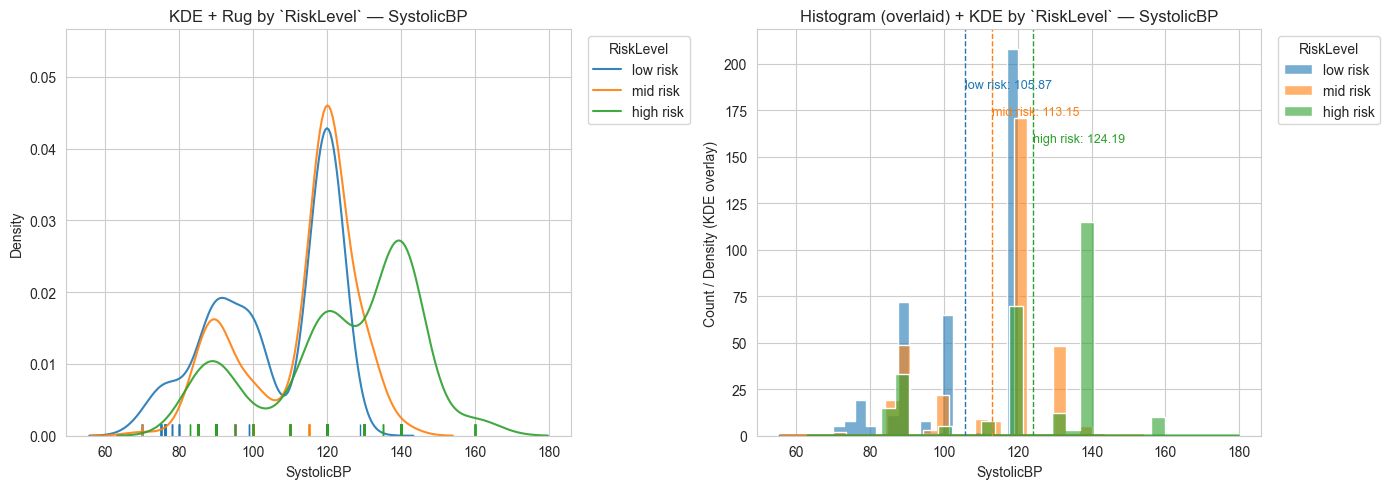


======================== Plotting: DiastolicBP ========================



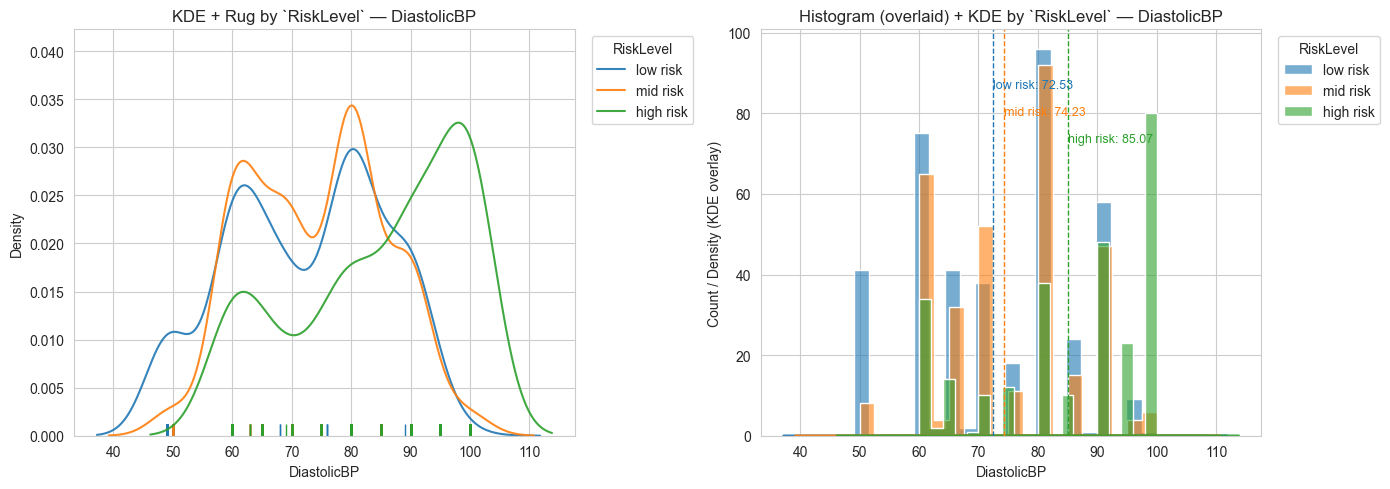


======================== Plotting: BS ========================



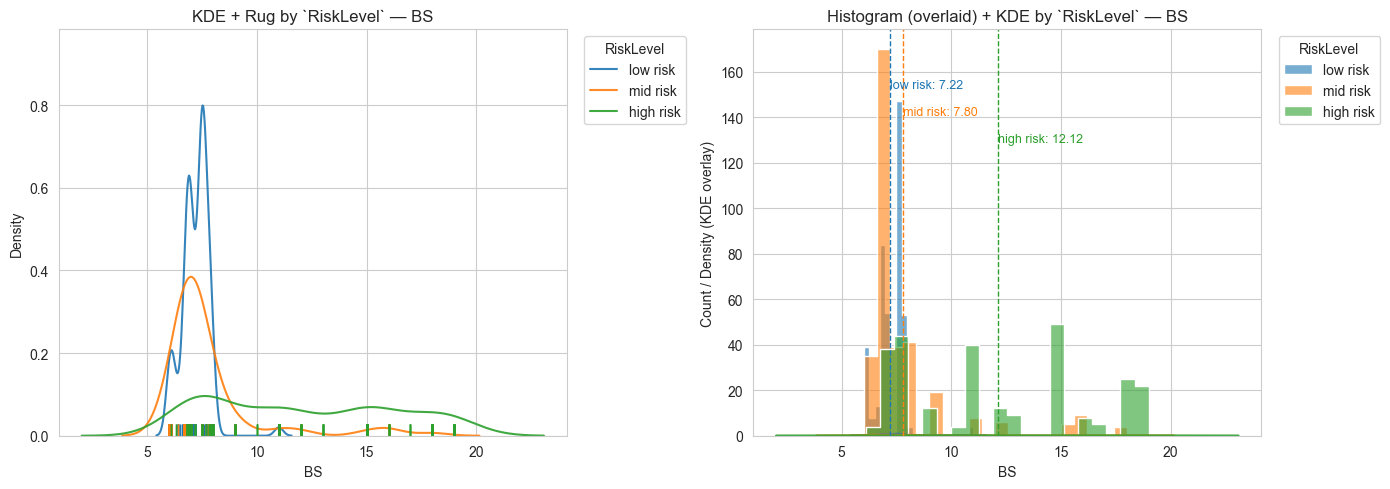


======================== Plotting: BodyTemp ========================



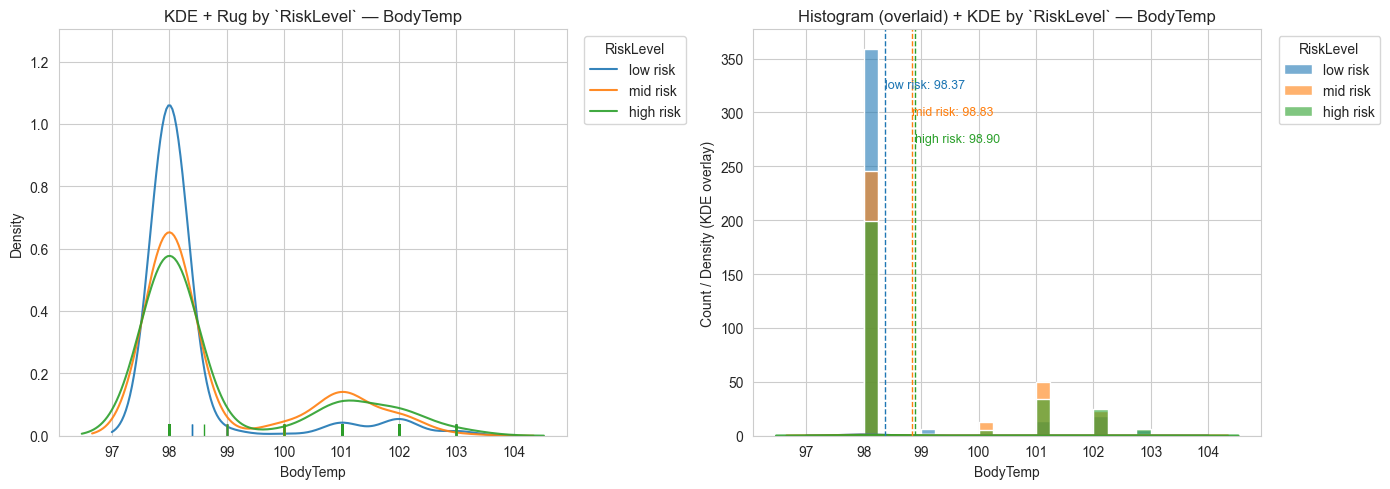


======================== Plotting: HeartRate ========================



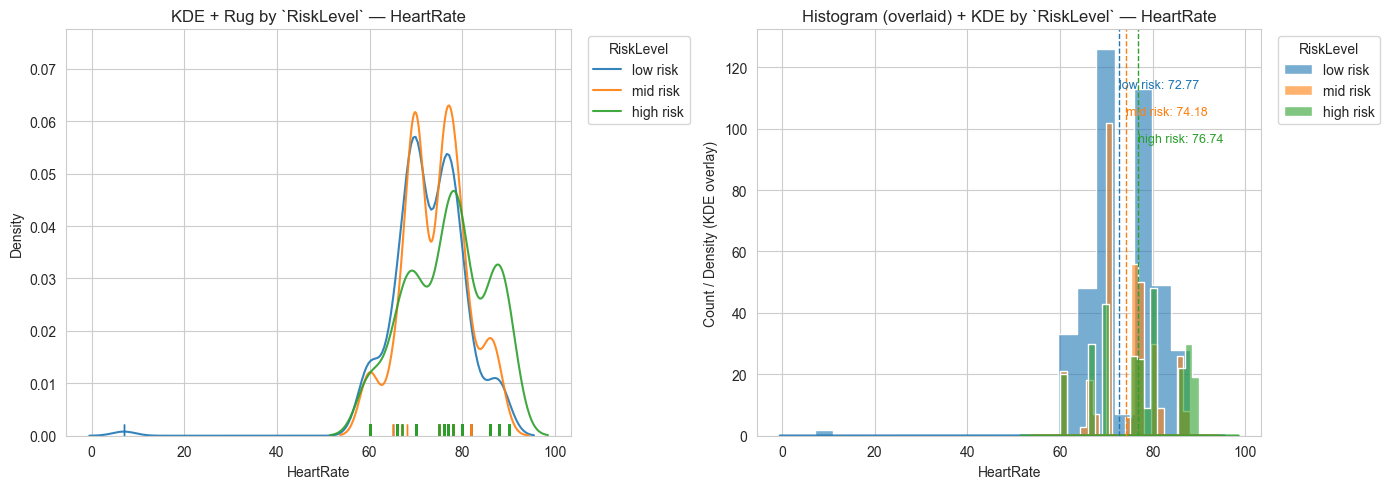



======================== Now displaying per-category DataFrames ========================


Category: low risk    (n_rows = 406)



,Feature,Count,Min,Max,Range,Mean,Median,Mode_rel,Std Dev,Variance,Skewness,Kurtosis,Q1,Q2,Q3,Any Zero?,Any Positive?,Any Negative?
0,Age,406,10.0,70.0,60.0,26.869458,22.0,12.261,13.122,172.178,1.281,0.765117,17.0,22.0,32.0,False,True,False
1,SystolicBP,406,70.0,129.0,59.0,105.866995,120.0,148.266,15.894,252.619,-0.529,-1.148169,90.0,120.0,120.0,False,True,False
2,DiastolicBP,406,49.0,100.0,51.0,72.534483,75.0,79.931,13.054,170.412,-0.171,-1.038904,60.0,75.0,80.0,False,True,False
3,BS,406,6.0,11.0,5.0,7.220271,7.5,8.059,0.646,0.417,1.549,9.846007,6.9,7.5,7.5,False,True,False
4,BodyTemp,406,98.0,103.0,5.0,98.368966,98.0,97.262,1.109,1.230,2.921,7.019023,98.0,98.0,98.0,False,True,False
5,HeartRate,406,7.0,88.0,81.0,72.770936,70.0,64.458,8.293,68.779,-2.332,17.909150,70.0,70.0,77.0,False,True,False



Category: mid risk    (n_rows = 336)



,Feature,Count,Min,Max,Range,Mean,Median,Mode_rel,Std Dev,Variance,Skewness,Kurtosis,Q1,Q2,Q3,Any Zero?,Any Positive?,Any Negative?
0,Age,336,10.0,60.0,50.0,28.363095,25.0,18.274,12.553,157.569,1.064,0.293526,19.0,25.0,32.0,False,True,False
1,SystolicBP,336,70.0,140.0,70.0,113.154762,120.0,133.690,14.983,224.495,-0.786,-0.577200,100.0,120.0,120.0,False,True,False
2,DiastolicBP,336,50.0,100.0,50.0,74.232143,75.0,76.536,11.490,132.024,0.046,-0.881025,65.0,75.0,80.0,False,True,False
3,BS,336,6.0,18.0,12.0,7.795744,7.0,5.409,2.286,5.224,2.897,8.061895,6.8,7.0,7.8,False,True,False
4,BodyTemp,336,98.0,103.0,5.0,98.833333,98.0,96.333,1.434,2.056,1.286,-0.052609,98.0,98.0,100.0,False,True,False
5,HeartRate,336,60.0,88.0,28.0,74.175595,76.0,79.649,6.767,45.799,-0.046,-0.324213,70.0,76.0,78.0,False,True,False



Category: high risk    (n_rows = 272)



,Feature,Count,Min,Max,Range,Mean,Median,Mode_rel,Std Dev,Variance,Skewness,Kurtosis,Q1,Q2,Q3,Any Zero?,Any Positive?,Any Negative?
0,Age,272,12.0,65.0,53.0,36.216912,35.0,32.566,13.032,169.838,0.006,-0.876145,25.0,35.0,48.0,False,True,False
1,SystolicBP,272,83.0,160.0,77.0,124.194853,130.0,141.610,20.227,409.139,-0.650,-0.610222,120.0,130.0,140.0,False,True,False
2,DiastolicBP,272,60.0,100.0,40.0,85.073529,90.0,99.853,14.112,199.161,-0.571,-1.026028,75.0,90.0,100.0,False,True,False
3,BS,272,6.1,19.0,12.9,12.122610,11.0,8.755,4.174,17.418,0.222,-1.340286,7.9,11.0,15.0,False,True,False
4,BodyTemp,272,98.0,103.0,5.0,98.899265,98.0,96.201,1.559,2.430,1.312,0.016422,98.0,98.0,100.0,False,True,False
5,HeartRate,272,60.0,90.0,30.0,76.742647,77.0,77.515,8.698,75.653,-0.206,-0.881233,70.0,77.0,86.0,False,True,False



Done — plots shown above, and per-category DataFrames displayed sequentially.


In [17]:
# ---------------- USER SETTINGS ----------------
cat_col = 'RiskLevel'       # categorical column to split by (your target)
top_n = 10                  # if > top_n categories, group rest into 'Other'
figsize_each = (14, 5)      # per-feature plot size
# ------------------------------------------------

# Safety checks
if cat_col not in data.columns:
    raise ValueError(f"Categorical column '{cat_col}' not found in data.columns")

# Prepare continuous columns (data_cont)
if 'data_cont' not in globals():
    data_cont = data.select_dtypes(include=[np.number]).copy()
if data_cont.shape[1] == 0:
    raise ValueError("No numeric (continuous) columns found in the dataframe.")

# Optionally group many small categories into 'Other'
vc = data[cat_col].value_counts(dropna=False)
if len(vc) > top_n:
    top_labels = vc.index[: top_n - 1].tolist()   # keep top_n-1 explicit
    def map_cat(x):
        return x if x in top_labels else 'Other'
    data['_cat_for_plot'] = data[cat_col].map(map_cat)
else:
    data['_cat_for_plot'] = data[cat_col].astype(str)

# final ordered list of categories
cat_order = data['_cat_for_plot'].value_counts().index.tolist()

# ---------------- PLOTTING: for each continuous feature, one row with two plots ----------------
palette = sns.color_palette(n_colors=len(cat_order))

for col in data_cont.columns:
    print(f"\n======================== Plotting: {col} ========================\n")

    # Prepare figure and axes: 1 row, 2 columns
    fig, axes = plt.subplots(1, 2, figsize=figsize_each)

    # LEFT: KDE + Rug (one KDE per category)
    ax = axes[0]
    for i, cat in enumerate(cat_order):
        series = data.loc[data['_cat_for_plot'] == cat, col].dropna()
        if series.empty:
            continue
        sns.kdeplot(series, fill=False, ax=ax, label=str(cat),
                    bw_method='scott', linewidth=1.5, alpha=0.9, color=palette[i])
        sns.rugplot(series, ax=ax, height=0.03, label=None, color=palette[i])

    ax.set_title(f"KDE + Rug by `{cat_col}` — {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Density")
    ax.legend(title=cat_col, bbox_to_anchor=(1.02, 1), loc='upper left')
    ax.grid(True)

    # RIGHT: Overlaid Histogram + KDE
    ax2 = axes[1]
    max_count = 0
    for i, cat in enumerate(cat_order):
        series = data.loc[data['_cat_for_plot'] == cat, col].dropna()
        if series.empty:
            continue
        sns.histplot(series, kde=False, stat='count', element='step', ax=ax2,
                     label=str(cat), bins=20, alpha=0.6, edgecolor=None, color=palette[i])
        sns.kdeplot(series, ax=ax2, linewidth=1.8, color=palette[i], alpha=0.9)

        hist_counts, _ = np.histogram(series, bins=20)
        if hist_counts.size and hist_counts.max() > max_count:
            max_count = hist_counts.max()

    ax2.set_title(f"Histogram (overlaid) + KDE by `{cat_col}` — {col}")
    ax2.set_xlabel(col)
    ax2.set_ylabel("Count / Density (KDE overlay)")
    ax2.legend(title=cat_col, bbox_to_anchor=(1.02, 1), loc='upper left')
    ax2.grid(True)

    # Add vertical mean lines & annotations on right plot
    for i, cat in enumerate(cat_order):
        series = data.loc[data['_cat_for_plot'] == cat, col].dropna()
        if series.empty:
            continue
        mu = series.mean()
        ax2.axvline(mu, color=palette[i], linestyle='--', linewidth=1)
        ypos = max_count * 0.9 - i * (max_count * 0.07) if max_count > 0 else 0.9
        ax2.text(mu, ypos, f"{cat}: {mu:.2f}", color=palette[i], fontsize=9)

    plt.tight_layout()
    plt.show()

# ---------------- After plotting: compute & display per-category summary DataFrames ----------------

def compute_distribution_summary(sub_df, cont_cols):
    rows = []
    for col in cont_cols:
        series = sub_df[col].dropna()
        if series.empty:
            row = {
                'Feature': col,
                'Count': 0,
                'Min': np.nan,
                'Max': np.nan,
                'Range': np.nan,
                'Mean': np.nan,
                'Median': np.nan,
                'Mode_rel': np.nan,
                'Std Dev': np.nan,
                'Variance': np.nan,
                'Skewness': np.nan,
                'Kurtosis': np.nan,
                'Q1': np.nan,
                'Q2': np.nan,
                'Q3': np.nan,
                'Any Zero?': False,
                'Any Positive?': False,
                'Any Negative?': False
            }
        else:
            row = {
                'Feature': col,
                'Count': int(series.count()),
                'Min': series.min(),
                'Max': series.max(),
                'Range': series.max() - series.min(),
                'Mean': series.mean(),
                'Median': series.median(),
                'Mode_rel': round(3 * series.median() - 2 * series.mean(), 3),
                'Std Dev': round(series.std(ddof=1), 3),
                'Variance': round(series.var(ddof=1), 3),
                'Skewness': round(series.skew(), 3),
                'Kurtosis': float(kurtosis(series, fisher=True, nan_policy='omit')),
                'Q1': round(series.quantile(0.25), 3),
                'Q2': round(series.quantile(0.50), 3),
                'Q3': round(series.quantile(0.75), 3),
                'Any Zero?': bool((series == 0).any()),
                'Any Positive?': bool((series > 0).any()),
                'Any Negative?': bool((series < 0).any())
            }
        rows.append(row)
    return pd.DataFrame(rows)

print("\n\n======================== Now displaying per-category DataFrames ========================\n")

for cat in cat_order:
    subset = data[data['_cat_for_plot'] == cat].copy()
    summary_df = compute_distribution_summary(subset, data_cont.columns)
    print("\n" + "="*60)
    print(f"Category: {cat}    (n_rows = {len(subset)})")
    print("="*60 + "\n")
    pd.set_option('display.max_columns', None)
    display(summary_df)

# Cleanup helper column (optional)
if '_cat_for_plot' in data.columns:
    data.drop(columns=['_cat_for_plot'], inplace=True)

print("\nDone — plots shown above, and per-category DataFrames displayed sequentially.")

### Correlation Analysis

#### Pearson and Spearman Correlation Matrices

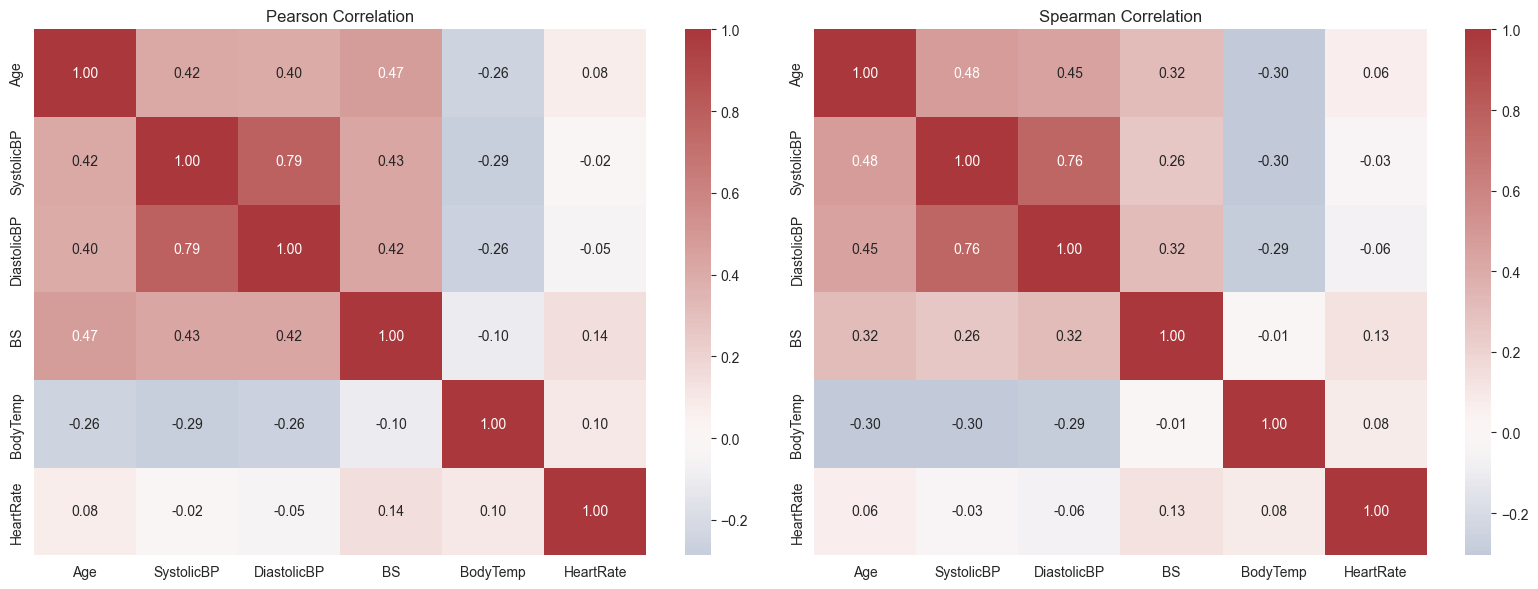

In [18]:
# Compute correlations for your continuous data
pearson = data_cont.corr(method='pearson')
spearman = data_cont.corr(method='spearman')

# ===========================
# 📌 PLOT BOTH HEATMAPS SIDE BY SIDE
# ===========================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(pearson, annot=True, fmt=".2f", cmap='vlag', center=0, ax=axes[0])
axes[0].set_title("Pearson Correlation")

sns.heatmap(spearman, annot=True, fmt=".2f", cmap='vlag', center=0, ax=axes[1])
axes[1].set_title("Spearman Correlation")

plt.tight_layout()
plt.show()

#### Top Correlated Feature Pairs

In [19]:
def top_pairs_with_sign(corr_df, top_n=10, strength_thresholds=(0.7, 0.3)):
    """
    Return top_n correlated feature pairs ordered by absolute correlation,
    but keep the signed correlation values and add Direction & Strength columns.
    
    Parameters:
      - corr_df: square correlation DataFrame (index and columns are feature names)
      - top_n: number of top unique pairs to return
      - strength_thresholds: tuple (strong_threshold, moderate_threshold)
           e.g. (0.7, 0.3) means:
             |r| >= 0.7 -> Strong
             0.3 <= |r| < 0.7 -> Moderate
             |r| < 0.3 -> Weak
    """
    # remove self correlations by masking diagonal
    mask = ~np.eye(corr_df.shape[0], dtype=bool)
    abs_corr = corr_df.abs().where(mask)

    # create a sorted series of (featureA, featureB) -> abs(corr)
    stacked = abs_corr.unstack().dropna().sort_values(ascending=False)

    unique_pairs = []
    seen = set()
    for (a, b), abs_val in stacked.items():
        # canonical key to avoid both (A,B) and (B,A)
        key = tuple(sorted((a, b)))
        if key in seen:
            continue
        seen.add(key)
        signed_val = corr_df.loc[a, b]  # real signed correlation
        unique_pairs.append((a, b, signed_val))
        if len(unique_pairs) >= top_n:
            break

    # Build DataFrame and add helper columns
    df = pd.DataFrame(unique_pairs, columns=["Feature 1", "Feature 2", "Correlation"])
    
    # Direction column
    def direction_label(x):
        if pd.isna(x):
            return "None"
        if x > 0:
            return "Positive"
        if x < 0:
            return "Negative"
        return "None"
    df['Direction'] = df['Correlation'].apply(direction_label)

    # Strength column based on absolute value
    strong_th, moderate_th = strength_thresholds
    def strength_label(x):
        if pd.isna(x):
            return "None"
        ax = abs(x)
        if ax >= strong_th:
            return "Strong"
        if ax >= moderate_th:
            return "Moderate"
        if ax > 0:
            return "Weak"
        return "None"
    df['Strength'] = df['Correlation'].apply(strength_label)

    # Also include absolute correlation for readability & sorting confirmation
    df['Abs Correlation'] = df['Correlation'].abs().round(3)

    # Reorder columns: keep signed correlation (rounded)
    df['Correlation'] = df['Correlation'].round(3)
    df = df[['Feature 1', 'Feature 2', 'Correlation', 'Abs Correlation', 'Direction', 'Strength']]

    return df

# ==== Example usage for YOUR DATA (using data_cont correlations) ====

top_pearson_signed = top_pairs_with_sign(pearson, top_n=10, strength_thresholds=(0.7, 0.3))
top_spearman_signed = top_pairs_with_sign(spearman, top_n=10, strength_thresholds=(0.7, 0.3))

print("Top Pearson (signed, with direction & strength):")
display(top_pearson_signed)

print("\nTop Spearman (signed, with direction & strength):")
display(top_spearman_signed)

Top Pearson (signed, with direction & strength):


,Feature 1,Feature 2,Correlation,Abs Correlation,Direction,Strength
0,DiastolicBP,SystolicBP,0.787,0.787,Positive,Strong
1,BS,Age,0.473,0.473,Positive,Moderate
2,BS,SystolicBP,0.425,0.425,Positive,Moderate
3,BS,DiastolicBP,0.424,0.424,Positive,Moderate
4,Age,SystolicBP,0.416,0.416,Positive,Moderate
5,Age,DiastolicBP,0.398,0.398,Positive,Moderate
6,SystolicBP,BodyTemp,-0.287,0.287,Negative,Weak
7,DiastolicBP,BodyTemp,-0.258,0.258,Negative,Weak
8,Age,BodyTemp,-0.255,0.255,Negative,Weak
9,BS,HeartRate,0.143,0.143,Positive,Weak



Top Spearman (signed, with direction & strength):


,Feature 1,Feature 2,Correlation,Abs Correlation,Direction,Strength
0,SystolicBP,DiastolicBP,0.757,0.757,Positive,Strong
1,Age,SystolicBP,0.485,0.485,Positive,Moderate
2,DiastolicBP,Age,0.446,0.446,Positive,Moderate
3,BS,DiastolicBP,0.322,0.322,Positive,Moderate
4,BS,Age,0.320,0.320,Positive,Moderate
5,Age,BodyTemp,-0.305,0.305,Negative,Moderate
6,BodyTemp,SystolicBP,-0.303,0.303,Negative,Moderate
7,DiastolicBP,BodyTemp,-0.289,0.289,Negative,Weak
8,SystolicBP,BS,0.262,0.262,Positive,Weak
9,BS,HeartRate,0.129,0.129,Positive,Weak


### Outlier Analysis 

#### Boxplot Visualization 

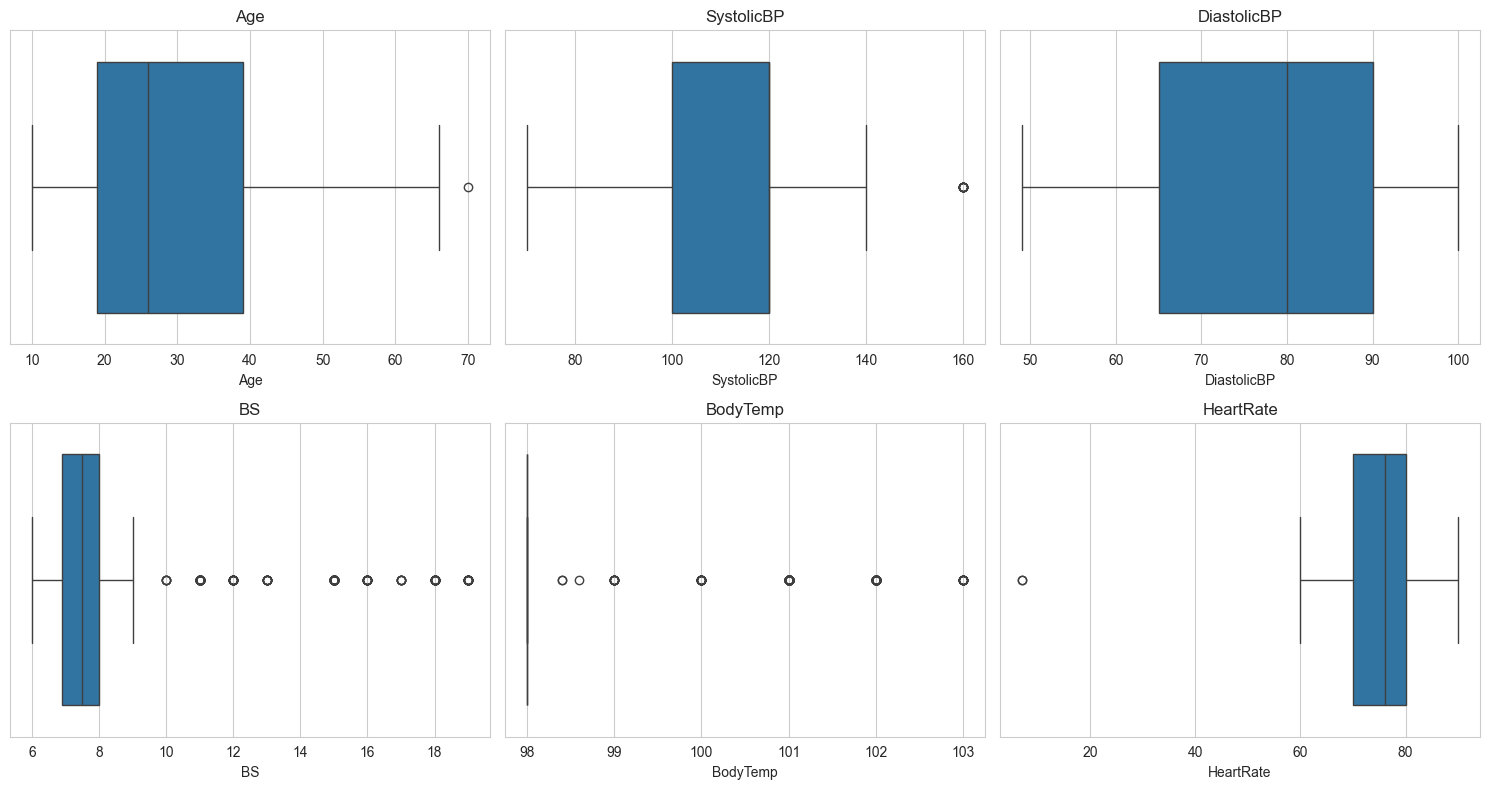

In [20]:
fig, axes = plt.subplots(2, 3, figsize=(15,8))

for ax, col in zip(axes.flatten(), data_cont.columns):
    sns.boxplot(x=data_cont[col], ax=ax)
    ax.set_title(col)

plt.tight_layout()
plt.show()

#### Violin Plot Visualization

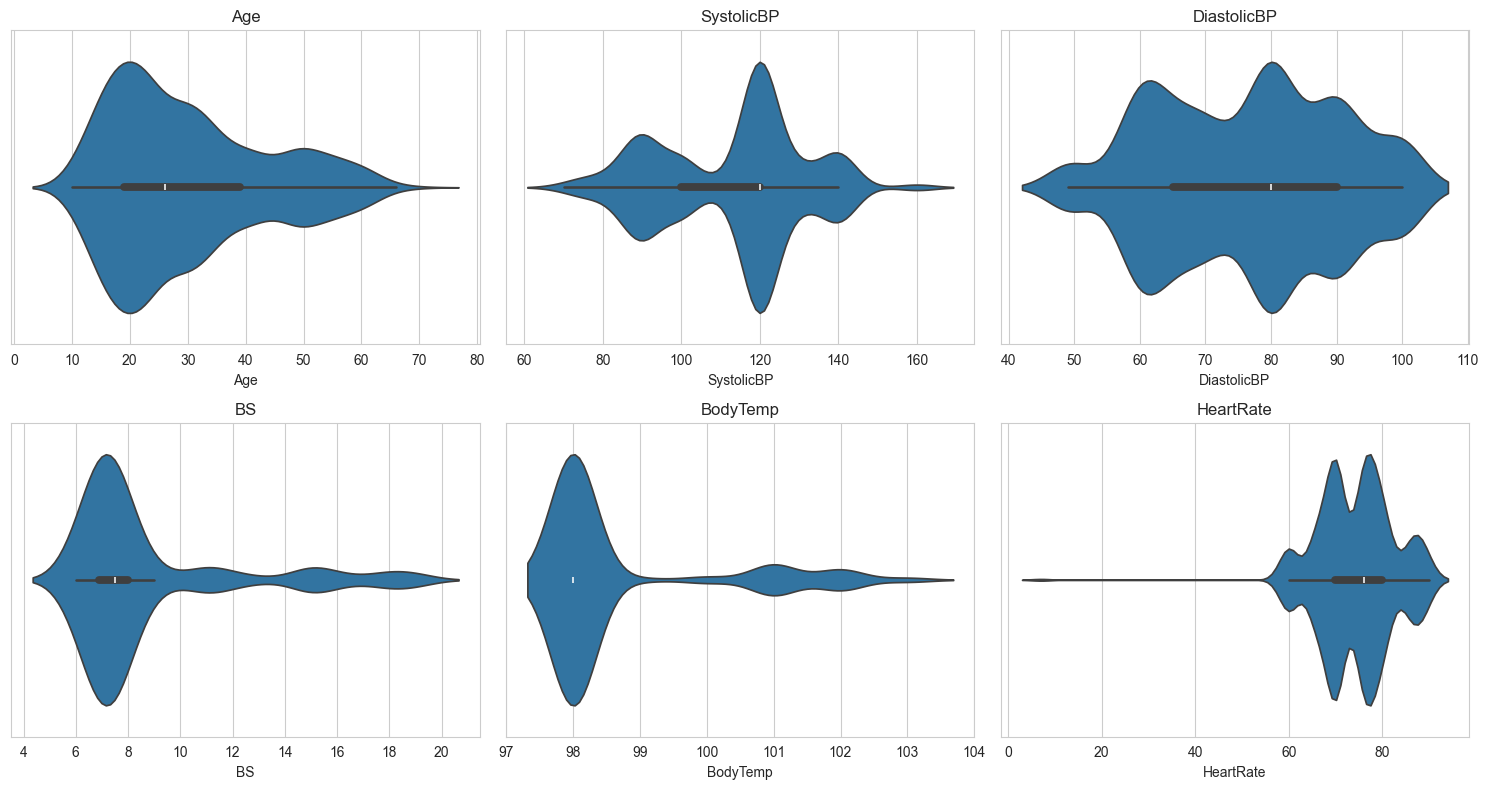

In [21]:
fig, axes = plt.subplots(2, 3, figsize=(15,8))

for ax, col in zip(axes.flatten(), data_cont.columns):
    sns.violinplot(x=data_cont[col], ax=ax)
    ax.set_title(col)

plt.tight_layout()
plt.show()

#### Pairwise Feature Analysis

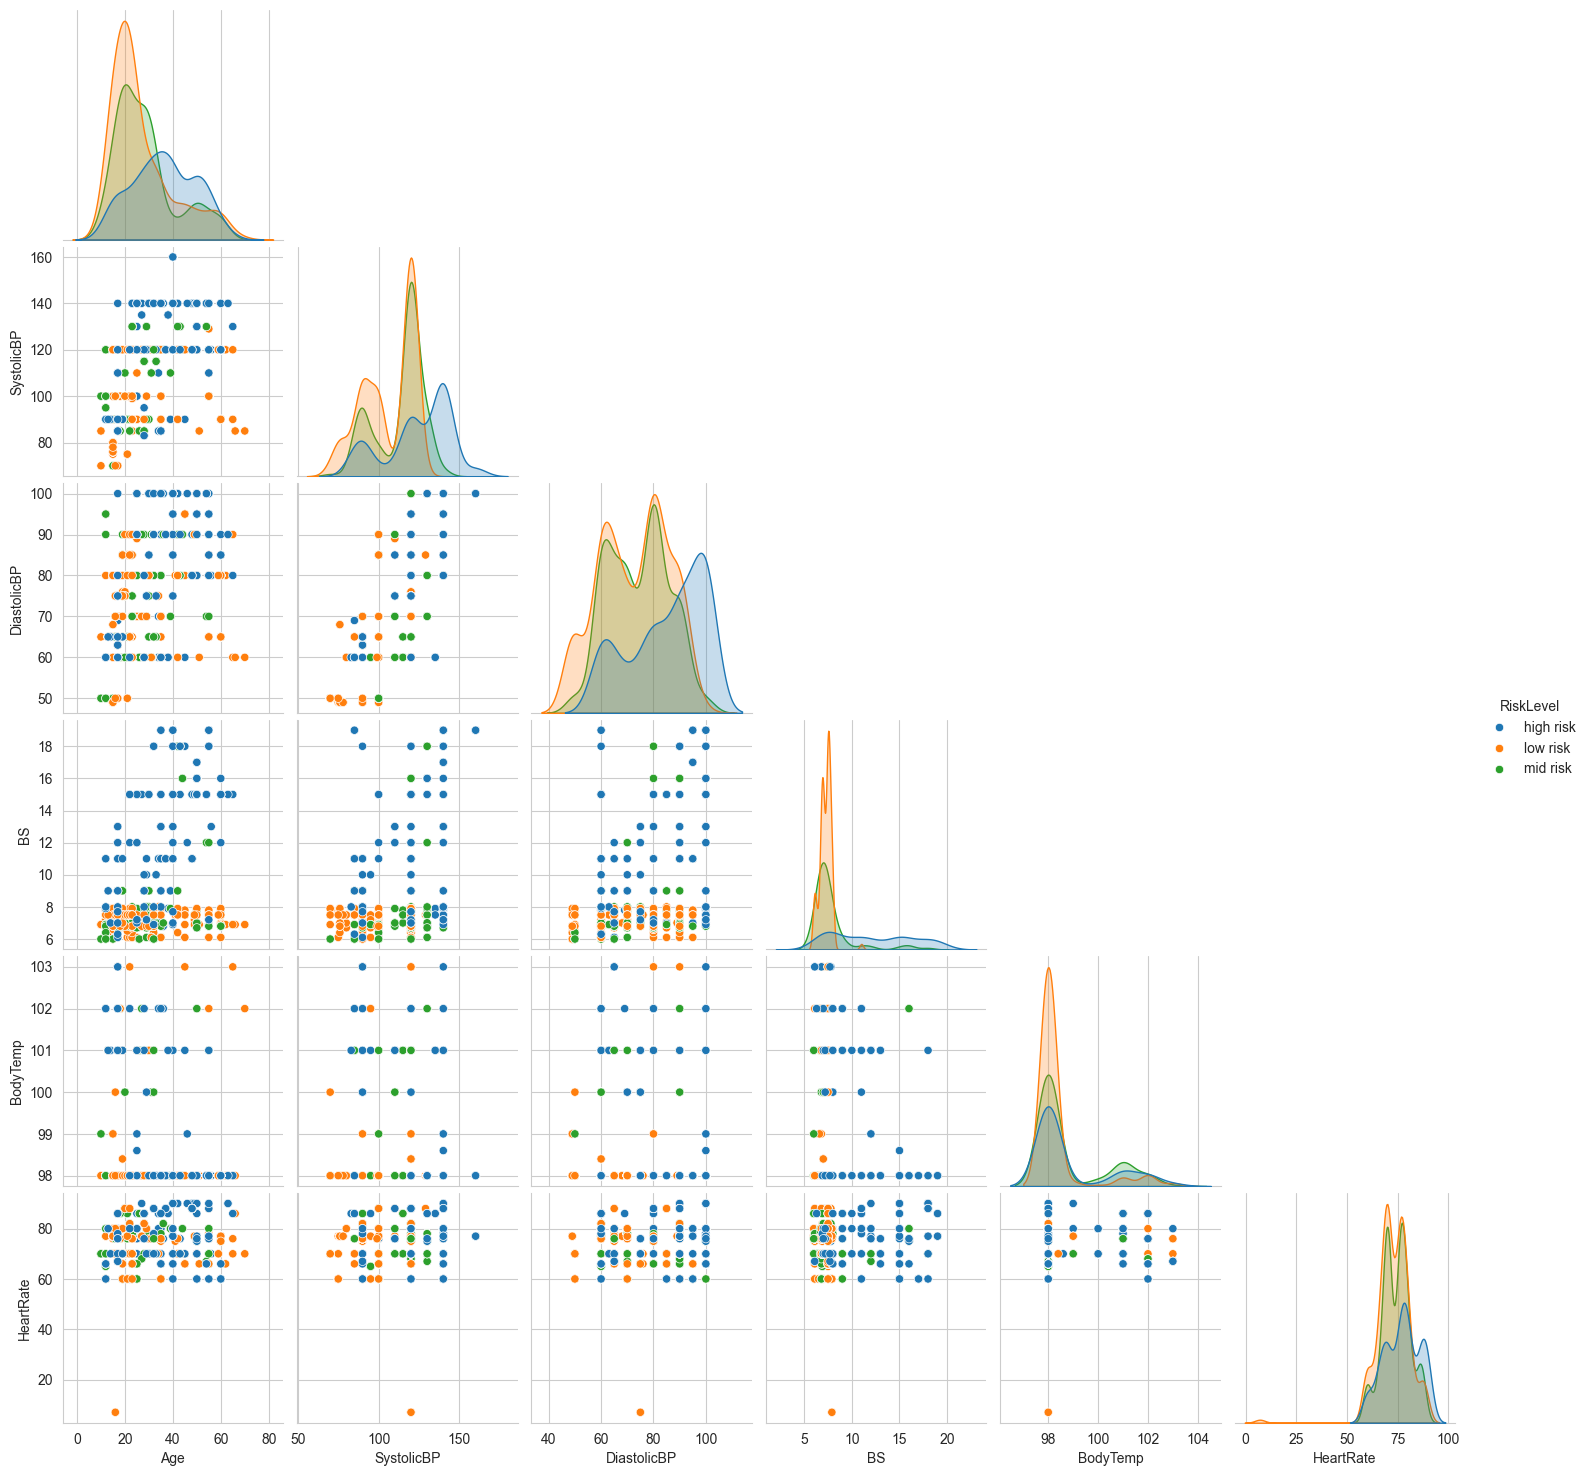

In [22]:
sns.pairplot(
    data,
    hue='RiskLevel',
    corner=True
)

plt.show()